In [1]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import Scribe as sb
import sys
import os

# import scanpy as sc
import dynamo as dyn
import seaborn as sns

dyn.dynamo_logger.main_silence()
dyn.configuration.set_figure_params('dynamo', background='white')

In [2]:
adata_labeling = dyn.sample_data.hematopoiesis()

In [3]:
gene = "TAL1"
dyn.pd.perturbation(adata_labeling, gene, [-100], emb_basis="umap")

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: perturbation ────────────────────────────────────────────╮
│  Duration: 3.1411s                                                 │
│  Shape:    1,947 x 1,956 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ grid_velocity_umap_perturbation                      │
│           │ ✚ history_log                                          │
│                                                                    │
│  ● OBSP   │ ✚ discrete_vector_field (array, 1947x1947)             │
│                                                                    │
│  ● OBSM   │ ✚ X_umap_perturbation (array, 1947x2)                  │
│           │ ✚ velocity_umap_perturbation (arr

In [4]:
dyn.pd.perturbation?

Signature:
dyn.pd.perturbation(
    adata: anndata._core.anndata.AnnData,
    genes: Union[str, list],
    expression: Union[float, list] = 10,
    perturb_mode: str = 'raw',
    cells: Union[list, numpy.ndarray, NoneType] = None,
    zero_perturb_genes_vel: bool = False,
    pca_key: Union[str, numpy.ndarray, NoneType] = None,
    PCs_key: Union[str, numpy.ndarray, NoneType] = None,
    pca_mean_key: Union[str, numpy.ndarray, NoneType] = None,
    basis: str = 'pca',
    emb_basis: str = 'umap',
    jac_key: str = 'jacobian_pca',
    X_pca: Optional[numpy.ndarray] = None,
    delta_Y: Optional[numpy.ndarray] = None,
    projection_method: str = 'fp',
    pertubation_method: str = 'j_delta_x',
    J_jv_delta_t: float = 1,
    delta_t: float = 1,
    add_delta_Y_key: Optional[str] = None,
    add_transition_key: Optional[str] = None,
    add_velocity_key: Optional[str] = None,
    add_embedding_key: Optional[str] = None,
)
Docstring:
In silico perturbation of single-cells and prediction

In [4]:
import omicverse as ov
ov.plot_set(font_path='Arial')
fb=ov.pl.ForbiddenCity()

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA A100-SXM4-40GB
      Memory: 39.4 GB | Compute: 8.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.10rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [5]:
from IPython.display import HTML
HTML(fb.visual_color(loc_range=(0,384),
                    num_per_row=24))

人籁,青粲,翠缥,水龙吟,碧山,石发,菉竹,庭芜绿,葱倩,漆姑,翠微,芰荷,青青,翠虬,官绿,油绿,莓莓,螺青,春辰,麴尘,欧碧,苍葭,兰苕,青玉案
,,,,,,,,,,,,,,,,,,,,,,,
碧滋,瓷秘,筠雾,竹香子,鸣珂,琬琰,出岫,王刍,春碧,执大象,青圭,绿沈,风入松,荩篋,绞衣,素綦,苍筤,天缥,卵色,沧浪,葭菼,山岚,冰台,青古
,,,,,,,,,,,,,,,,,,,,,,,
醽醁,渌波,青楸,缥碧,翠涛,青梅,雀梅,苔古,蕉月,干山翠,翕赩,结绿,绿云,丹罽,黄丹,檎丹,银朱,洛神珠,珊瑚赫,朱孔阳,丹雘,水华朱,胭脂虫,朱樱
,,,,,,,,,,,,,,,,,,,,,,,
大繎,顺圣,爵头,麒麟竭,苕荣,扶光,十样锦,海天霞,驿刚,朱颜酡,赦霞,赦尾,缙云,小红,琼琚,岱赭,朱柿,艳炽,鹤顶红,赤缇,纁黄,棠梨,朱殷,石榴裙
,,,,,,,,,,,,,,,,,,,,,,,
朱草,赤灵,佛赤,綪茷,朱湛,丹秫,木兰,杨妃,盈盈,银红,粉米,桃夭,水红,夕岚,彤管,咸池,莲红,雌霓,縓缘,长春,渥赭,红䵂,紫梅,绛纱
,,,,,,,,,,,,,,,,,,,,,,,
茹藘,美人祭,唇脂,牙绯,鞓红,葡萄褐,蚩尤旗,紫矿,紫诰,苏方,霁红,蜜褐,福色,黪紫,龙膏烛,苏梅,琅环紫,胭脂水,紫茎屏风,红踯躅,胭脂紫,魏红,紫府,魏紫


In [4]:
color_dict={
    'Bas':fb.get_color(name='朱樱')['color_html'].values[0], 
    'Ery':fb.get_color(name='二绿')['color_html'].values[0], 
    'GMP-like':fb.get_color(name='魏红')['color_html'].values[0], 
    'HSC':fb.get_color(name='盈盈')['color_html'].values[0], 
    'MEP-like':fb.get_color(name='杨妃')['color_html'].values[0], 
    'Meg':fb.get_color(name='群青')['color_html'].values[0], 
    'Mon':fb.get_color(name='赪紫')['color_html'].values[0], 
    'Neu':fb.get_color(name='凝夜紫')['color_html'].values[0], 
    
}

In [5]:
color_dict

{'Bas': '#8c1c24',
 'Ery': '#5ca49c',
 'GMP-like': '#a43464',
 'HSC': '#fcd4e4',
 'MEP-like': '#f494a4',
 'Meg': '#2c5ca4',
 'Mon': '#8c1c74',
 'Neu': '#442454'}

In [6]:
color_dict={'Mon': '#b88c7a',
 'Meg': '#5b7d80',
 'MEP-like': '#6c05e8',
 'Ery': '#5d373b',
 'Bas': '#d70000',
 'GMP-like': '#ff4600',
 'HSC': '#c35dbb',
 'Neu': '#2f3ea8'}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


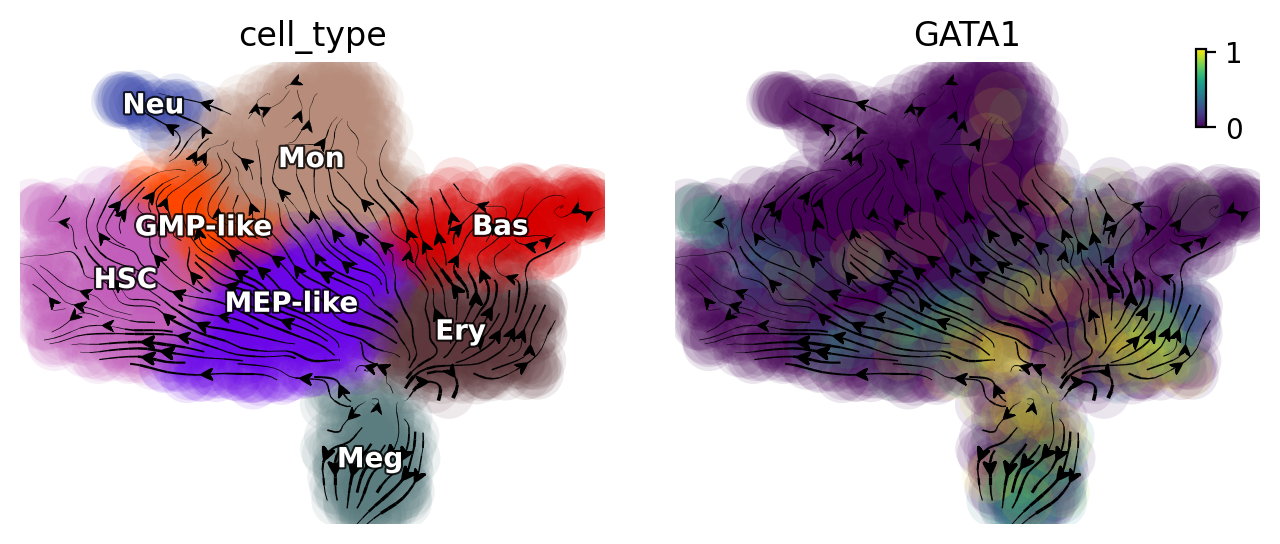

In [15]:
gene = "GATA1"
dyn.pd.perturbation(adata_labeling, gene, [-100], emb_basis="umap")
dyn.pl.streamline_plot(adata_labeling, color=["cell_type", gene], 
                       basis="umap_perturbation",figsize=(4,3))

In [18]:
dyn.pd.KO?

Signature:
dyn.pd.KO(
    adata: anndata._core.anndata.AnnData,
    KO_genes: Union[str, list],
    vecfld: Optional[Callable] = None,
    vf_key: str = 'VecFld',
    basis: str = 'pca',
    emb_basis: str = 'umap',
    velocity_ko_wt_difference: bool = False,
    add_ko_basis_key: Optional[str] = None,
    add_embedding_key: Optional[str] = None,
    store_vf_ko: bool = False,
    add_vf_ko_key: Optional[str] = None,
    return_vector_field_class: bool = True,
) -> Optional[dynamo.vectorfield.scVectorField.KOVectorField]
Docstring:
In silico knockout genes (and thus the vector field function) and prediction of cell fate after knockout.

Args:
    adata: an Anndata object with the vector field function for PCA learned.
    KO_genes: The gene or list of genes that will be used to perform in-silico knockout.
    vecfld: The vector field function.
    vf_key: A key to the vector field functions in adata.uns.
    basis: The basis in which the vector field function is created.
    emb_basis

|-----> In silico knockout GATA1
|-----> Project the high dimensional vector field after KO to umap.
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


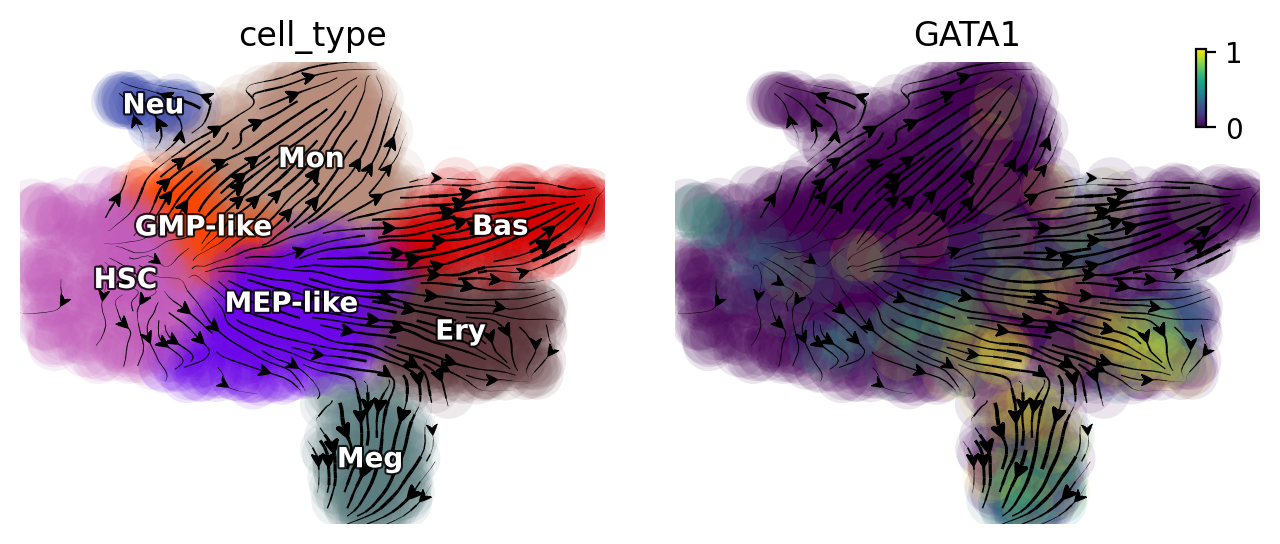

In [16]:
gene = "GATA1"
dyn.pd.KO(adata_labeling, gene, emb_basis="umap")
dyn.pl.streamline_plot(adata_labeling, color=["cell_type", gene], 
                       basis="umap_KO",figsize=(4,3))

In [17]:
1

1

In [12]:
adata_labeling

AnnData object with n_obs × n_vars = 1947 × 1956
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', 'inlier_prob_umap_ori', 'obs_vf_angle_umap_ori', 'curvature_umap_ori'
    var: 'gene_name', 'gene_id', 'nCells', 'nCounts', 'pass_basic

In [5]:
gene = "GATA1"
dyn.pd.perturbation(adata_labeling, gene, [-100], emb_basis="umap")

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


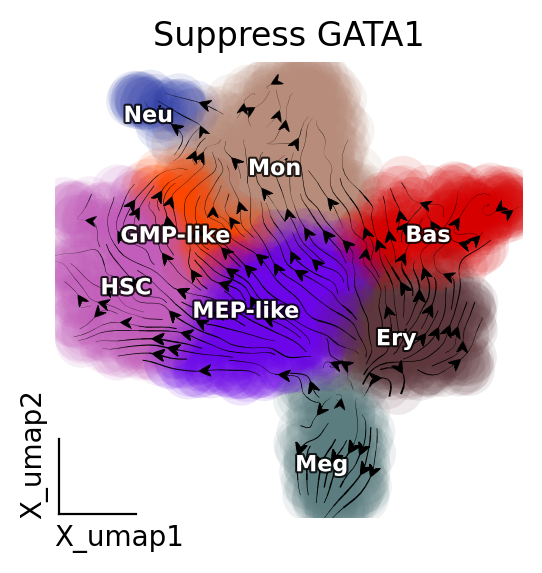

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('Suppress GATA1',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_suppress_gata1.svg', dpi=300, bbox_inches='tight')

In [7]:
gene = "SPI1"
dyn.pd.perturbation(adata_labeling, gene, [-100], emb_basis="umap")

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


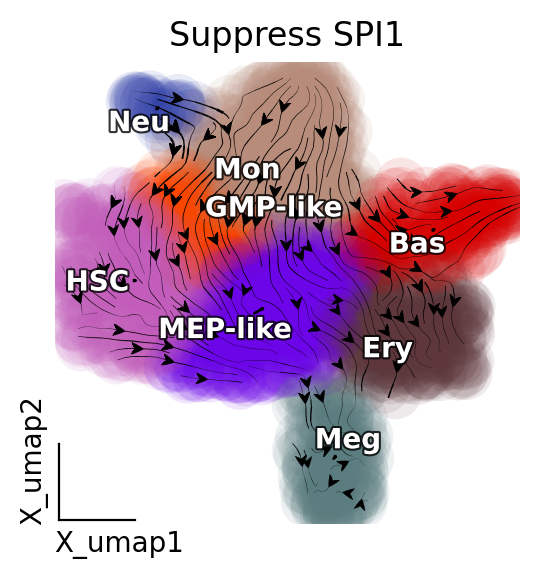

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Suppress {gene}',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_suppress_{gene}.svg', dpi=300, bbox_inches='tight')

In [9]:
selected_genes =  [ "SPI1", "GATA1"]
# expr_vals = [-100, -100]
expr_vals = [-100, -15]
dyn.pd.perturbation(adata_labeling, selected_genes, expr_vals, emb_basis="umap")


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


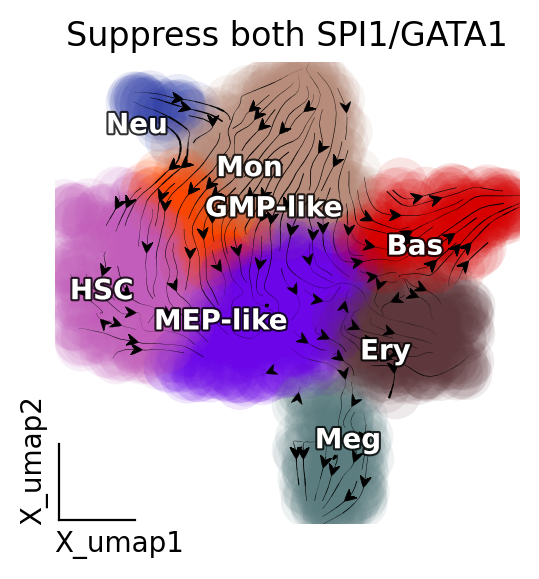

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Suppress both SPI1/GATA1',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_suppress_spi1_gata1.svg', dpi=300, bbox_inches='tight')

In [11]:
gene = "KLF1"
dyn.pd.perturbation(adata_labeling, gene, [100], emb_basis="umap")


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


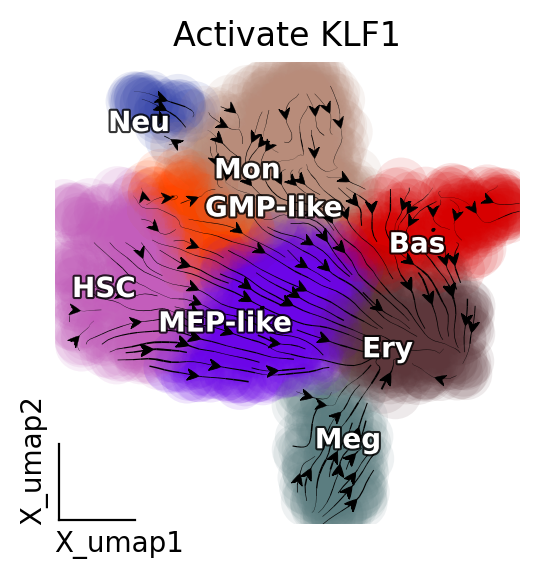

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Activate {gene}',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_activate_{gene}.svg', dpi=300, bbox_inches='tight')

In [13]:
selected_genes =  [ "GATA1", "KLF1"]
# expr_vals = [-100, -100]
expr_vals = [100, -100]
dyn.pd.perturbation(adata_labeling, selected_genes, expr_vals, emb_basis="umap")


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


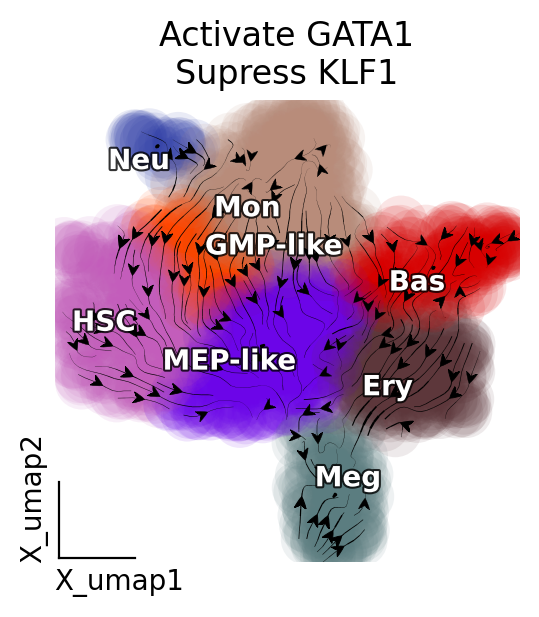

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Activate GATA1\nSupress KLF1',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_activate_gata1_supress_klf1.svg', dpi=300, bbox_inches='tight')

In [15]:
selected_genes =  [ "GATA1", "KLF1","SPI1"]
# expr_vals = [-100, -100]
expr_vals = [100, 100,100]
dyn.pd.perturbation(adata_labeling, selected_genes, expr_vals, emb_basis="umap")


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


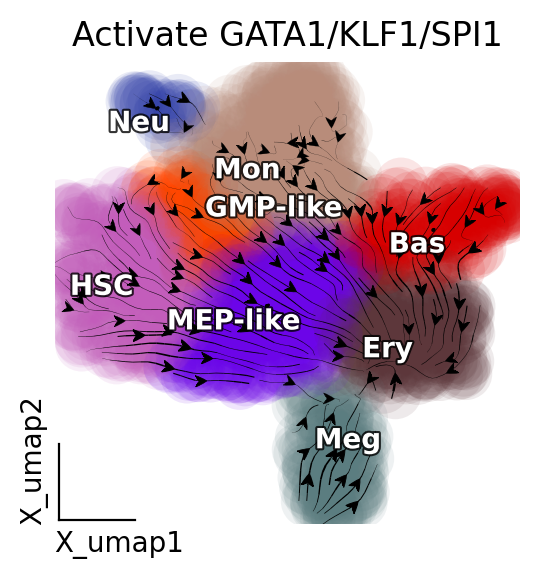

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Activate GATA1/KLF1/SPI1',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig5/dynamo_activate_gata1_spi1_klf1.svg', dpi=300, bbox_inches='tight')

In [42]:
fig.savefig(f'figures/fig5/dynamo_activate_gata1_spi1_klf1.svg', dpi=300, bbox_inches='tight')

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


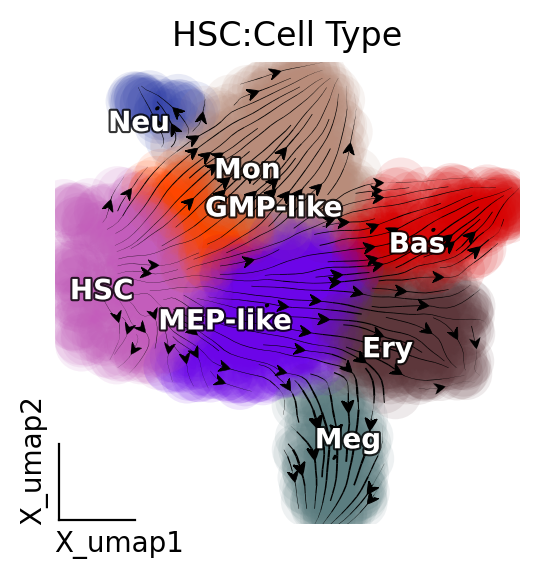

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:Cell Type',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)


fig.savefig(f'figures/fig4/dynamo_HSC_Velo.png', dpi=300, bbox_inches='tight')

fig.savefig(f'figures/fig4/dynamo_HSC_Velo.svg', dpi=300, bbox_inches='tight')

In [19]:
gene = "FLI1"
dyn.pd.perturbation(adata_labeling, gene, [-100], emb_basis="umap")

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: perturbation ────────────────────────────────────────────╮
│  Duration: 3.0827s                                                 │
│  Shape:    1,947 x 1,956 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


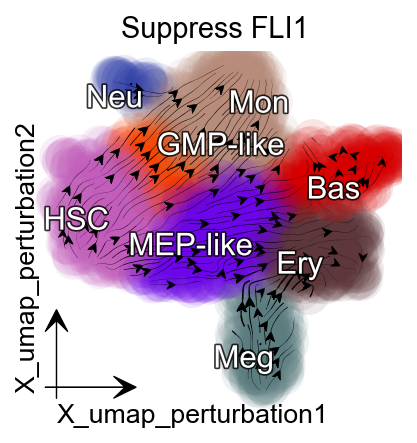

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       #color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Suppress {gene}',fontsize=13)
fig.savefig(f'figures/dynode_sfig2/dynamo_suppress_{gene}.svg')
fig.savefig(f'figures/dynode_sfig2/dynamo_suppress_{gene}.png', dpi=300, bbox_inches='tight')

In [29]:
gene = "FLI1"
dyn.pd.perturbation(adata_labeling, gene, [100], emb_basis="umap")

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: perturbation ────────────────────────────────────────────╮
│  Duration: 3.0888s                                                 │
│  Shape:    1,947 x 1,956 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


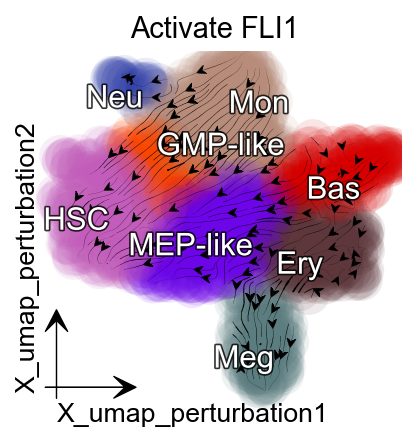

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, 
                       basis='umap_perturbation',
                       color=['cell_type'], 
                       #color_key=color_dict,
                       #title='DG:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title(f'Activate {gene}',fontsize=13)
fig.savefig(f'figures/dynode_sfig2/dynamo_activate_{gene}.svg')
fig.savefig(f'figures/dynode_sfig2/dynamo_activate_{gene}.png', dpi=300, bbox_inches='tight')

In [7]:
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA A100-SXM4-40GB
      Memory: 39.4 GB | Compute: 8.0
✅ plot_set complete.

